# YOLO11 — 그린바이오 첨단농장 식물 부위 검출 - Colab 용

[AI Hub 그린바이오 기반 식품소재 첨단농장 데이터] 샘플을 이용해
**Ultralytics YOLO11**로 작물 이미지 속 **식물 부위(줄기·잎·뿌리)** 를 검출하는 예제입니다.

| 항목 | 설명 |
|------|------|
| 데이터 | `green_bio_farm.zip` (작물 9종, 이미지-라벨 25,602쌍) |
| 라벨 원본 | 부위별 **2점 폴리라인** (`labels.label_divide` / `label_points`) |
| 변환 | 폴리라인 양 끝점을 감싸는 B-box → YOLO 포맷 |
| 클래스 | `stem`(줄기) · `leaf`(잎) · `root`(뿌리) |
| 모델 | **YOLO11s** (`yolo11s.pt`) |
| 선행 EDA | `16_Green_Bio_Farm_EDA.ipynb` |

<br>

> **Colab 실행 순서**: ① 런타임 → GPU 선택 ② 왼쪽 파일 탭에 `green_bio_farm.zip` 업로드
> (또는 아래 셀에서 Google Drive 마운트) ③ 위에서부터 순서대로 실행.
>
> 원본 25,602장을 모두 학습하면 시간이 매우 오래 걸리므로, 아래 `SUBSET_PER_CROP` 로
> 작물별 이미지 수를 제한해 예제 규모로 축소합니다. 전체 학습 시 값만 키우면 됩니다.


## 0. 환경 설정

Google Drive 에 zip 을 둔 경우 아래 두 줄의 주석을 풀어 마운트한 뒤,
`ZIP_SRC` 를 실제 경로로 바꿔 `/content` 로 복사하세요.
```python
# from google.colab import drive; drive.mount('/content/drive')
# import shutil; shutil.copy('/content/drive/MyDrive/green_bio_farm.zip', '/content/green_bio_farm.zip')
```

In [1]:
%pip install -U ultralytics

import json
import random
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import torch
import yaml
from IPython.display import Image as IPImage, display
from ultralytics import YOLO, __version__

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DEVICE = 0 if torch.cuda.is_available() else "cpu"

ROOT = Path("/content") if IN_COLAB else Path.cwd()
if not (ROOT / "green_bio_farm.zip").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "green_bio_farm.zip").exists():
            ROOT = parent
            break

ZIP_PATH = ROOT / "green_bio_farm.zip"
DATA_ROOT = ROOT / "green_bio_farm"
YOLO_DIR = ROOT / "green_bio_farm_yolo"
YAML_PATH = YOLO_DIR / "green_bio_farm.yaml"

RAW_DIR_NAME = "01.\uc6d0\ucc9c\ub370\uc774\ud130"       # 01.원천데이터
LABEL_DIR_NAME = "02.\ub77c\ubca8\ub9c1\ub370\uc774\ud130"   # 02.라벨링데이터

# 부위(label_divide) → 검출 클래스 (렌더링 호환 위해 로마자 사용)
PART_NAME_MAP = {"\uc90c\uae30": "stem", "\uc904\uae30": "stem", "\uc78e": "leaf", "\ubfcc\ub9ac": "root"}
CLASS_NAMES = ["stem", "leaf", "root"]
CLASS_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}

# 예제 규모 축소 옵션
SUBSET_PER_CROP = 250    # 작물 9종 × 250 ≈ 2,250장 (전체 학습 시 크게 설정)
VAL_RATIO = 0.2
SEED = 42

MODEL_NAME = "yolo11s.pt"
CONF_THRESH = 0.25
EXPERIMENT = "yolo11_green_bio_farm"

env_label = "Colab" if IN_COLAB else "\ub85c\uceec"
print(f"\ud658\uacbd       : {env_label}")
print(f"Ultralytics: {__version__}")
print(f"Device     : {DEVICE}")
print(f"ROOT       : {ROOT.resolve()}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 10.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
환경       : Colab
Ultralytics: 8.4.146
Device     : 0
ROOT       : /content


## 1. 데이터 준비 (압축 해제 + YOLO 변환)

- `green_bio_farm.zip` 은 최상위에 `green_bio_farm/` 래퍼 폴더가 있어 벗겨서 전개합니다.
- 폴더 계층: `01.원천데이터 / <작물> / <생육단계> / <촬영방향> / *.jpg` (라벨은 `02.라벨링데이터` 아래 동일 경로 `*.json`).
- 각 JSON의 `label_points`(2점 폴리라인)를 감싸는 사각형에 여백을 준 뒤 YOLO 정규화 좌표로 변환합니다.
  좌표는 JSON의 `imagewidth/imageheight`(원본 해상도) 기준이므로 정규화하면 실제 JPG 크기와 무관합니다.
- 작물별 층화 랜덤 분할로 `VAL_RATIO` 만큼을 검증셋으로 뺍니다.

In [2]:
def data_is_ready(root: Path) -> bool:
    if not root.exists():
        return False
    jpgs = [p for p in root.rglob("*.jpg") if "eda" not in p.parts]
    jsons = [p for p in root.rglob("*.json") if "eda" not in p.parts]
    return len(jpgs) > 0 and len(jsons) > 0


def has_correct_korean_paths(root: Path) -> bool:
    if not root.exists():
        return False
    dirs = [p.name for p in root.iterdir() if p.is_dir() and p.name != "eda"]
    return RAW_DIR_NAME in dirs and LABEL_DIR_NAME in dirs


def extract_zip(zip_path: Path, extract_to: Path, force: bool = False) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f"\uc555\ucd95 \ud30c\uc77c\uc774 \uc5c6\uc2b5\ub2c8\ub2e4: {zip_path}")
    extract_to.mkdir(parents=True, exist_ok=True)
    if not force and data_is_ready(extract_to) and has_correct_korean_paths(extract_to):
        return
    for child in extract_to.iterdir():
        if child.is_dir() and child.name != "eda":
            shutil.rmtree(child)
    with zipfile.ZipFile(zip_path) as zf:
        for info in zf.infolist():
            # 한글 깨짐 방지: UTF-8 플래그가 없으면 cp437→cp949 재해석, 불가하면 원본 유지
            try:
                if not (info.flag_bits & 0x800):
                    name = info.filename.encode("cp437").decode("cp949")
                else:
                    name = info.filename
            except (UnicodeEncodeError, UnicodeDecodeError):
                name = info.filename

            parts = name.split("/")
            if parts and parts[0] == extract_to.name:   # 최상위 래퍼 폴더 제거
                name = "/".join(parts[1:])
            if not name:
                continue
            target = extract_to / name
            if info.is_dir() or name.endswith("/"):
                target.mkdir(parents=True, exist_ok=True)
            else:
                target.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(info) as src, open(target, "wb") as dst:
                    dst.write(src.read())


def seg_to_bbox(seg, img_w, img_h):
    """2점(또는 그 이상) 폴리라인을 감싸는 axis-aligned 박스 + 여백 → (x1, y1, x2, y2) 픽셀."""
    xs = [p[0] for p in seg]
    ys = [p[1] for p in seg]
    x1, x2 = min(xs), max(xs)
    y1, y2 = min(ys), max(ys)
    pad_x = max((x2 - x1) * 0.25, img_w * 0.015)
    pad_y = max((y2 - y1) * 0.25, img_h * 0.015)
    x1, x2 = x1 - pad_x, x2 + pad_x
    y1, y2 = y1 - pad_y, y2 + pad_y
    x1, y1 = max(0.0, x1), max(0.0, y1)
    x2, y2 = min(float(img_w), x2), min(float(img_h), y2)
    return x1, y1, x2, y2


def xyxy_to_yolo(x1, y1, x2, y2, img_w, img_h):
    return (x1 + x2) / 2 / img_w, (y1 + y2) / 2 / img_h, (x2 - x1) / img_w, (y2 - y1) / img_h


def _flatten_divide(raw):
    out = []
    for d in raw or []:
        out.append(d[0] if isinstance(d, list) and d else d)
    return [x for x in out if x]


def prepare_yolo_dataset(data_root: Path, output_dir: Path) -> dict:
    label_root = data_root / LABEL_DIR_NAME
    raw_root = data_root / RAW_DIR_NAME
    rng = random.Random(SEED)

    # 작물별로 JSON 수집 후 SUBSET_PER_CROP 만큼 샘플링
    by_crop: dict[str, list[Path]] = {}
    for jp in label_root.rglob("*.json"):
        crop = jp.relative_to(label_root).parts[0]
        by_crop.setdefault(crop, []).append(jp)

    picked: list[tuple[Path, str]] = []   # (json_path, split)
    for crop, jsons in sorted(by_crop.items()):
        jsons = sorted(jsons)
        rng.shuffle(jsons)
        jsons = jsons[:SUBSET_PER_CROP]
        n_val = int(len(jsons) * VAL_RATIO)
        for i, jp in enumerate(jsons):
            picked.append((jp, "val" if i < n_val else "train"))

    for split in ("train", "val"):
        (output_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (output_dir / "labels" / split).mkdir(parents=True, exist_ok=True)

    stats = {"train": 0, "val": 0, "skipped": 0, "instances": 0}
    cls_counter = Counter()

    for json_path, split in picked:
        data = json.loads(json_path.read_text(encoding="utf-8-sig"))
        meta = data.get("images", {})
        lab = data.get("labels", {}) or {}
        divides = _flatten_divide(lab.get("label_divide"))
        segments = lab.get("label_points", []) or []
        if not divides or not segments:
            stats["skipped"] += 1
            continue

        rel = json_path.relative_to(label_root).with_suffix(".jpg")
        src_img = raw_root / rel
        if not src_img.exists():
            stats["skipped"] += 1
            continue

        w = meta.get("imagewidth")
        h = meta.get("imageheight")
        if not w or not h:
            stats["skipped"] += 1
            continue

        lines = []
        for div, seg in zip(divides, segments):
            cls_name = PART_NAME_MAP.get(div)
            if cls_name is None or not (isinstance(seg, list) and len(seg) >= 2):
                continue
            x1, y1, x2, y2 = seg_to_bbox(seg, w, h)
            if x2 - x1 < 1 or y2 - y1 < 1:
                continue
            xc, yc, nw, nh = xyxy_to_yolo(x1, y1, x2, y2, w, h)
            if not (0 < nw <= 1 and 0 < nh <= 1):
                continue
            lines.append(f"{CLASS_TO_ID[cls_name]} {xc:.6f} {yc:.6f} {nw:.6f} {nh:.6f}")
            cls_counter[cls_name] += 1

        if not lines:
            stats["skipped"] += 1
            continue

        stem = "__".join(json_path.relative_to(label_root).with_suffix("").parts)
        shutil.copy2(src_img, output_dir / "images" / split / f"{stem}.jpg")
        (output_dir / "labels" / split / f"{stem}.txt").write_text("\n".join(lines) + "\n", encoding="utf-8")
        stats[split] += 1
        stats["instances"] += len(lines)

    YAML_PATH.write_text(
        f"path: {output_dir.resolve()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"nc: {len(CLASS_NAMES)}\n"
        f"names:\n" + "".join(f"  - {n}\n" for n in CLASS_NAMES),
        encoding="utf-8",
    )
    stats["yaml"] = str(YAML_PATH)
    stats["per_class"] = dict(cls_counter)
    return stats


need_extract = not data_is_ready(DATA_ROOT) or not has_correct_korean_paths(DATA_ROOT)
extract_zip(ZIP_PATH, DATA_ROOT, force=need_extract)

if YOLO_DIR.exists():
    shutil.rmtree(YOLO_DIR)   # 이전 변환 결과·캐시 제거 후 재생성

stats = prepare_yolo_dataset(DATA_ROOT, YOLO_DIR)
print("YOLO \ub370\uc774\ud130\uc14b:", {k: v for k, v in stats.items() if k not in ("per_class",)})
print("\ud074\ub798\uc2a4\ubcc4 \uc778\uc2a4\ud134\uc2a4:", stats["per_class"])
print(f"train \uc774\ubbf8\uc9c0: {len(list((YOLO_DIR / 'images/train').glob('*.jpg')))}")
print(f"val   \uc774\ubbf8\uc9c0: {len(list((YOLO_DIR / 'images/val').glob('*.jpg')))}")


YOLO 데이터셋: {'train': 1800, 'val': 450, 'skipped': 0, 'instances': 4722, 'yaml': '/content/green_bio_farm_yolo/green_bio_farm.yaml'}
클래스별 인스턴스: {'leaf': 2247, 'stem': 2026, 'root': 449}
train 이미지: 1800
val   이미지: 450


## 2. YOLO11 모델 학습

In [3]:
# RTX 3060 기준 약 20~40분 / Colab T4 기준 약 30~50분 (SUBSET_PER_CROP=250, EPOCHS=50)
# Colab A100  약 11분 소요
# Colab 무료 런타임에서 시간이 부족하면 SUBSET_PER_CROP 을 120, EPOCHS 를 30 정도로 낮추세요.
EPOCHS = 50
BATCH = 16
IMGSZ = 640

model = YOLO(MODEL_NAME)
results = model.train(
    data=str(YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    name=EXPERIMENT,
    exist_ok=True,
    patience=15,
    plots=True,
    verbose=True,
)

BEST_WEIGHTS = Path(results.save_dir) / "weights" / "best.pt"
print(f"\ucd5c\uc801 \uac00\uc911\uce58: {BEST_WEIGHTS.resolve()}")


Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/green_bio_farm_yolo/green_bio_farm.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_green_bi

## 3. 검증 (Validation)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 832.4±179.4 MB/s, size: 16.4 KB)
val: Scanning /content/green_bio_farm_yolo/labels/val.cache... 450 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 450/450 145.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 29/29 8.9it/s 3.3s
                   all        450        947      0.903      0.947      0.927      0.807
                  stem        408        408      0.961       0.98       0.98      0.775
                  leaf        450        450      0.749      0.871      0.815      0.723
                  root         89         89          1      0.989      0.985      0.924
Speed: 0.7ms preprocess, 2.0ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/ru

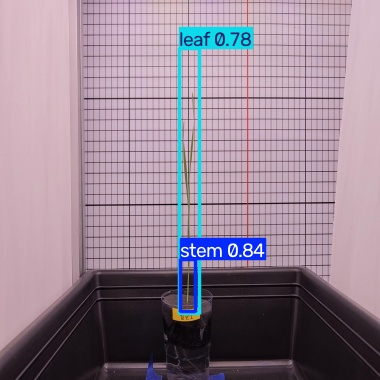

저장: /content/runs/detect/yolo11_green_bio_farm_val_probe


In [4]:
best_model = YOLO(str(BEST_WEIGHTS))
metrics = best_model.val(data=str(YAML_PATH), imgsz=IMGSZ, device=DEVICE, conf=CONF_THRESH)
print(f"mAP50    : {metrics.box.map50:.4f}")
print(f"mAP50-95 : {metrics.box.map:.4f}")
ap50_by_cls = {int(c): float(a) for c, a in zip(metrics.box.ap_class_index, metrics.box.ap50)}
for i, name in best_model.names.items():
    ap = ap50_by_cls.get(i)
    print(f"  {name:5s} AP50: {ap:.4f}" if ap is not None else f"  {name:5s} AP50: -  (val 인스턴스 없음)")

# 검증 이미지 1장 추론 미리보기
val_images = sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))
if val_images:
    probe = best_model.predict(source=str(val_images[0]), conf=CONF_THRESH, save=True,
                               name=f"{EXPERIMENT}_val_probe")
    out_dir = Path(probe[0].save_dir)
    pred_img = next(out_dir.glob("*.jpg"))
    display(IPImage(filename=str(pred_img), width=700))
    print(f"\uc800\uc7a5: {out_dir}")


## 4. 이미지 추론 (Predict)


image 1/1 /content/green_bio_farm_yolo/images/train/01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240725_232542_SV_W12.jpg: 640x640 1 stem, 1 leaf, 10.3ms
Speed: 1.8ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/yolo11_green_bio_farm_predict

[01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240725_232542_SV_W12.jpg]
  - stem: conf=0.852
  - leaf: conf=0.791


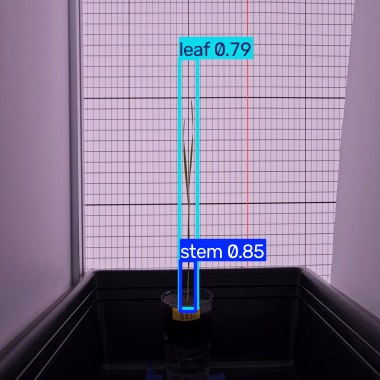


image 1/1 /content/green_bio_farm_yolo/images/train/01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_034242_SV_W14.jpg: 640x640 1 stem, 1 leaf, 9.8ms
Speed: 1.6ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/yolo11_green_bio_farm_predict

[01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_034242_SV_W14.jpg]
  - stem: conf=0.859
  - leaf: conf=0.787


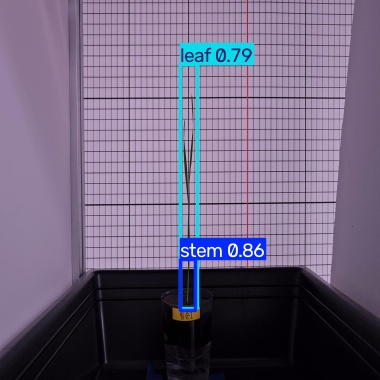


image 1/1 /content/green_bio_farm_yolo/images/train/01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_085043_SV_W14.jpg: 640x640 1 stem, 1 leaf, 9.8ms
Speed: 1.9ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/yolo11_green_bio_farm_predict

[01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_085043_SV_W14.jpg]
  - stem: conf=0.845
  - leaf: conf=0.779


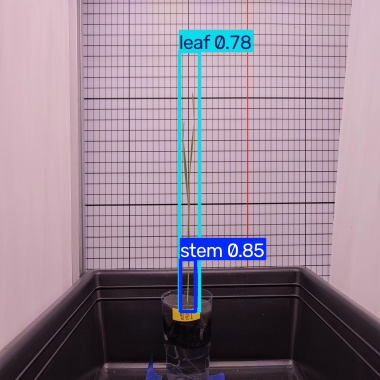


image 1/1 /content/green_bio_farm_yolo/images/val/01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_085443_SV_W14.jpg: 640x640 1 stem, 1 leaf, 9.6ms
Speed: 1.6ms preprocess, 9.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/yolo11_green_bio_farm_predict

[01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_085443_SV_W14.jpg]
  - stem: conf=0.843
  - leaf: conf=0.778


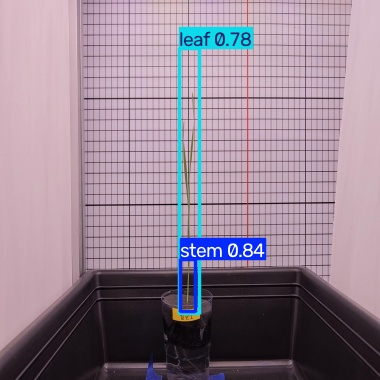


image 1/1 /content/green_bio_farm_yolo/images/val/01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240727_093249_SV_W21.jpg: 640x640 1 stem, 1 leaf, 10.7ms
Speed: 1.5ms preprocess, 10.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/yolo11_green_bio_farm_predict

[01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240727_093249_SV_W21.jpg]
  - stem: conf=0.796
  - leaf: conf=0.771


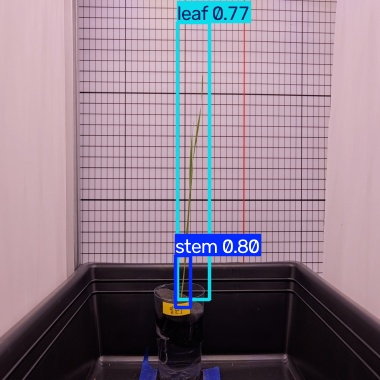

In [5]:
sample_images = sorted((YOLO_DIR / "images" / "train").glob("*.jpg"))[:3]
sample_images += sorted((YOLO_DIR / "images" / "val").glob("*.jpg"))[:2]

for img_path in sample_images:
    preds = best_model.predict(source=str(img_path), conf=CONF_THRESH, save=True,
                               name=f"{EXPERIMENT}_predict")
    out_dir = Path(preds[0].save_dir)
    pred_img = out_dir / img_path.name
    print(f"\n[{img_path.name}]")
    for box in preds[0].boxes:
        cls_name = best_model.names[int(box.cls)]
        print(f"  - {cls_name}: conf={float(box.conf):.3f}")
    display(IPImage(filename=str(pred_img), width=600))


## 5. 검증셋 추론 → 영상 출력

검증셋 이미지를 순서대로 추론하고 탐지 결과를 하나의 MP4 영상으로 저장합니다.
용량이 커지지 않도록 `VIDEO_MAX` 장까지만 사용하고, 노트북에는 GIF 미리보기를 표시합니다.

검증 이미지 추론 시작: 120장
  [  1/120] 01.밀순__01.생장__01.사이드뷰__SP01_L_B01_G_F05_S2_240726_085443_SV_W14.jpg — 탐지 2건
  [ 20/120] 01.밀순__01.생장__02.탑뷰__SP01_L_B01_G_F05_S2_240801_101108_TV_W01.jpg — 탐지 2건
  [ 40/120] 01.밀순__02.수확__02.탑뷰__SP01_L_B01_P_F05_S2_240831_024600_TV_W28.jpg — 탐지 2건
  [ 60/120] 02.새싹인삼_개량종__01.생장__01.사이드뷰__SP02_L_B02_G_F03_S2_240810_120103_SV_W12.jpg — 탐지 3건
  [ 80/120] 02.새싹인삼_개량종__01.생장__01.사이드뷰__SP02_L_B02_G_F03_S2_240909_204200_SV_W17.jpg — 탐지 3건
  [100/120] 02.새싹인삼_개량종__02.수확__02.탑뷰__SP02_L_B02_P_F03_S2_240912_051900_TV_W25.jpg — 탐지 3건
  [120/120] 03.새싹인삼_연풍__01.생장__01.사이드뷰__SP03_L_B03_G_F03_S2_240901_112800_SV_W17.jpg — 탐지 4건

영상 저장: /content/runs/detect/yolo11_green_bio_farm_val_video/val_inference.mp4
GIF 미리보기: /content/runs/detect/yolo11_green_bio_farm_val_video/val_inference.preview.gif


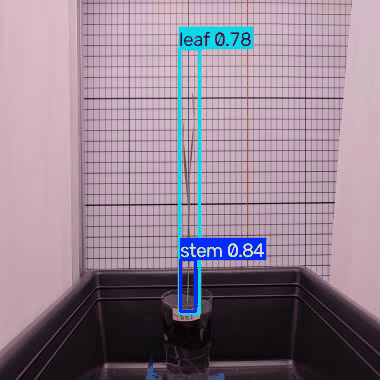

In [6]:
import cv2
from PIL import Image as PILImage

VIDEO_MAX = 120
FPS = 8

VAL_DIR = YOLO_DIR / "images" / "val"
val_images = sorted(VAL_DIR.glob("*.jpg"))[:VIDEO_MAX]
if not val_images:
    raise FileNotFoundError(f"\uac80\uc99d \uc774\ubbf8\uc9c0\uac00 \uc5c6\uc2b5\ub2c8\ub2e4: {VAL_DIR}")

VIDEO_OUT_DIR = ROOT / "runs" / "detect" / f"{EXPERIMENT}_val_video"
VIDEO_OUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_PATH = VIDEO_OUT_DIR / "val_inference.mp4"
GIF_PATH = VIDEO_PATH.with_suffix(".preview.gif")

frames_bgr = []
print(f"\uac80\uc99d \uc774\ubbf8\uc9c0 \ucd94\ub860 \uc2dc\uc791: {len(val_images)}\uc7a5")
for i, img_path in enumerate(val_images):
    r = best_model.predict(source=str(img_path), conf=CONF_THRESH, device=DEVICE, verbose=False)
    frames_bgr.append(r[0].plot())
    if i == 0 or i == len(val_images) - 1 or (i + 1) % 20 == 0:
        print(f"  [{i + 1:>3}/{len(val_images)}] {img_path.name} \u2014 \ud0d0\uc9c0 {len(r[0].boxes)}\uac74")

h, w = frames_bgr[0].shape[:2]
writer = cv2.VideoWriter(str(VIDEO_PATH), cv2.VideoWriter_fourcc(*"mp4v"), FPS, (w, h))
for frame in frames_bgr:
    writer.write(frame)
writer.release()


def make_gif_preview(video_path: Path, gif_path: Path, every_n: int = 3,
                     max_frames: int = 30, width: int = 640) -> Path:
    cap = cv2.VideoCapture(str(video_path))
    frames, idx = [], 0
    while len(frames) < max_frames:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % every_n == 0:
            pil = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            if pil.width > width:
                pil = pil.resize((width, int(pil.height * width / pil.width)), PILImage.LANCZOS)
            frames.append(pil)
        idx += 1
    cap.release()
    if not frames:
        raise RuntimeError(f"GIF \uc0dd\uc131 \uc2e4\ud328: {video_path}")
    frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=150, loop=0)
    return gif_path


make_gif_preview(VIDEO_PATH, GIF_PATH)
print(f"\n\uc601\uc0c1 \uc800\uc7a5: {VIDEO_PATH.resolve()}")
print(f"GIF \ubbf8\ub9ac\ubcf4\uae30: {GIF_PATH.resolve()}")
display(IPImage(filename=str(GIF_PATH), width=700))


## 6. CLI 참고

```bash
# 학습
yolo detect train model=yolo11s.pt data=green_bio_farm_yolo/green_bio_farm.yaml epochs=50 imgsz=640 batch=16 device=0 name=yolo11_green_bio_farm

# 추론
yolo predict model=runs/detect/yolo11_green_bio_farm/weights/best.pt source=green_bio_farm_yolo/images/val conf=0.25 save=True
```

### 참고
- 이 예제의 B-box는 **부위 길이 측정용 폴리라인**을 사각형으로 감싼 것이라, 실제 부위 외곽선과는 다릅니다.
  (여백 비율은 `seg_to_bbox` 의 `0.25`, `0.015` 로 조정)
- 샘플 JPG는 **380×380 축소본**이지만 라벨 좌표는 원본(1920/3840) 기준 → YOLO 정규화로 해상도 문제는 없습니다.
- 전체 데이터 학습 시 `SUBSET_PER_CROP` 를 크게(예: `10**9`), `EPOCHS` 를 늘리세요.
- 분할 기준을 촬영방향(`탑뷰`)이나 특정 작물 홀드아웃으로 바꾸면 일반화 성능을 더 엄격히 평가할 수 있습니다.
